# 🐧🐧Tarea 3 --- IELE756 🐧🐧
**Equipo Pinguino conformado por** : Hellen Quiñones, Gustavo Sánchez

**Region**: -no asignada-

**Date**: 03-05-26

**Link al repositorio de GitHub**: https://github.com/hellenelizabethqm-netizen/iele756-region-XXXX

### 🐧**PARTE 0: cargamos los archivos de todos los grupos**🐧  
Primero cargamos las bibliotecas necesarias y descomprimimos el archivo entregado por el curso, que reunía los outputs de los distintos grupos. Luego buscamos todos los archivos `.csv` dentro de la carpeta extraída, incluso los que estaban guardados en subcarpetas, para poder identificar y separar correctamente las tablas de `census`, `ENO` y `GRD`.

Después de eso, consolidamos los archivos de cada fuente en una base maestra común. En esta etapa también revisamos la consistencia de los códigos de comuna, la cantidad de comunas únicas y la presencia de duplicados, para asegurarnos de que las tres bases quedaran alineadas antes de empezar el análisis.

Además, fue necesario eliminar algunos archivos problemáticos de ciertos grupos. En varios casos, los archivos no habían sido subidos con el formato que correspondía; algunos no coincidían con los códigos de comuna que supuestamente representaban, y en otros casos se detectaron archivos que eran duplicados de los enviados por otro grupo. Por esa razón, esos archivos se excluyeron del proceso de unión y análisis. La idea no fue “limpiar” resultados, sino evitar que observaciones mal identificadas o repetidas distorsionaran la base maestra y los resultados posteriores.

In [1]:
import zipfile
import os
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf



#Extraer el zip en una carpeta local del proyecto
with zipfile.ZipFile("files_export.zip", "r") as z:
    z.extractall("files_export")

#Buscar todos los csv dentro de esa carpeta, incluso dentro de subcarpetas
all_csv = glob.glob(os.path.join("files_export", "**", "*.csv"), recursive=True)

print("Total CSV encontrados:", len(all_csv))
for f in all_csv[:15]:
    print(f)

Total CSV encontrados: 39
files_export\census_team10.csv
files_export\census_team12.csv
files_export\census_team19.csv
files_export\census_team20.csv
files_export\eno_team10.csv
files_export\eno_team12.csv
files_export\eno_team19.csv
files_export\eno_team20.csv
files_export\grd_team10.csv
files_export\grd_team12.csv
files_export\grd_team19.csv
files_export\grd_team20.csv
files_export\Team01\census_team01.csv
files_export\Team01\eno_team01.csv
files_export\Team01\grd_team01.csv


In [2]:
census_files = [f for f in all_csv if "census" in os.path.basename(f).lower()]
eno_files = [f for f in all_csv if "eno" in os.path.basename(f).lower()]
grd_files = [f for f in all_csv if "grd" in os.path.basename(f).lower()]

print("Census:", len(census_files))
print("ENO:", len(eno_files))
print("GRD:", len(grd_files))

Census: 13
ENO: 13
GRD: 13


In [3]:
census_master = pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True)
eno_master = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True)
grd_master = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True)

print("census_master:", census_master.shape)
print("eno_master:", eno_master.shape)
print("grd_master:", grd_master.shape)

print("\nUnique codigo_comuna")
print("census:", census_master["codigo_comuna"].nunique())
print("eno:", eno_master["codigo_comuna"].nunique())
print("grd:", grd_master["codigo_comuna"].nunique())

census_master: (34, 13)
eno_master: (34, 8)
grd_master: (34, 13)

Unique codigo_comuna
census: 34
eno: 34
grd: 34


In [4]:
print("Duplicados census:")
print(census_master["codigo_comuna"].value_counts()[census_master["codigo_comuna"].value_counts() > 1])

print("\nDuplicados eno:")
print(eno_master["codigo_comuna"].value_counts()[eno_master["codigo_comuna"].value_counts() > 1])

print("\nDuplicados grd:")
print(grd_master["codigo_comuna"].value_counts()[grd_master["codigo_comuna"].value_counts() > 1])

Duplicados census:
Series([], Name: count, dtype: int64)

Duplicados eno:
Series([], Name: count, dtype: int64)

Duplicados grd:
Series([], Name: count, dtype: int64)


In [5]:
census_set = set(census_master["codigo_comuna"])
eno_set = set(eno_master["codigo_comuna"])
grd_set = set(grd_master["codigo_comuna"])

print("En census pero no en ENO:", sorted(census_set - eno_set))
print("En census pero no en GRD:", sorted(census_set - grd_set))

print("En ENO pero no en census:", sorted(eno_set - census_set))
print("En ENO pero no en GRD:", sorted(eno_set - grd_set))

print("En GRD pero no en census:", sorted(grd_set - census_set))
print("En GRD pero no en ENO:", sorted(grd_set - eno_set))

En census pero no en ENO: []
En census pero no en GRD: []
En ENO pero no en census: []
En ENO pero no en GRD: []
En GRD pero no en census: []
En GRD pero no en ENO: []


In [6]:
print("NaN en census:", census_master["codigo_comuna"].isna().sum())
print("NaN en eno:", eno_master["codigo_comuna"].isna().sum())
print("NaN en grd:", grd_master["codigo_comuna"].isna().sum())

NaN en census: 0
NaN en eno: 0
NaN en grd: 0


In [7]:
census_master = census_master[census_master["codigo_comuna"].notna()].copy()
eno_master = eno_master[eno_master["codigo_comuna"].notna()].copy()
grd_master = grd_master[grd_master["codigo_comuna"].notna()].copy()

census_master["codigo_comuna"] = census_master["codigo_comuna"].astype(int)
eno_master["codigo_comuna"] = eno_master["codigo_comuna"].astype(int)
grd_master["codigo_comuna"] = grd_master["codigo_comuna"].astype(int)

In [9]:
print(census_master.columns.tolist())

['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio']


In [10]:
analytical_df = census_master.merge(
    eno_master,
    on="codigo_comuna",
    how="outer",
    suffixes=("_census", "_eno")
).merge(
    grd_master,
    on="codigo_comuna",
    how="outer",
    suffixes=("", "_grd")
)

print("Shape final:", analytical_df.shape)
analytical_df.head()

Shape final: (34, 32)


,codigo_comuna,nombre_comuna_census,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,...,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,5101,Valparaíso,284938,272618,12320,4.320000,36.8,30.1,11.400000,11.900000,...,22541,1639,6.780000,5.600000,5.700000,4.900000,1.920000,2.840000,Embarazo y parto | Enfermedades circulatorias ...,848.610000
1,5102,Casablanca,29876,27607,2269,7.590000,34.5,28.7,10.800000,10.300000,...,1963,171,8.010000,4.800000,4.900000,4.100000,1.780000,2.150000,Embarazo y parto | Enfermedades digestivas | E...,714.290000
2,13104,Conchalí,121587,103271,17686,14.545963,39.0,34.0,11.325066,11.983653,...,9346,1215,0.115046,6.366632,6.616413,4.445267,1.429505,0.036834,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",868.596149
3,13105,El Bosque,155257,143714,10652,6.860882,37.0,31.0,10.971926,12.114083,...,9046,471,4.949039,7.223915,7.369335,4.430998,1.774614,3.425449,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",612.983634
4,13107,Huechuraba,101808,92790,8381,8.280000,36.0,35.0,12.770000,14.120000,...,5743,427,6.920000,6.090000,6.220000,4.270000,1.370000,3.420000,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",606.000000


In [11]:
print("Comunas únicas en tabla final:", analytical_df["codigo_comuna"].nunique())
print("Filas con codigo_comuna missing:", analytical_df["codigo_comuna"].isna().sum())

Comunas únicas en tabla final: 34
Filas con codigo_comuna missing: 0


In [12]:
final_set = set(analytical_df["codigo_comuna"])

print("En census pero no en final:", sorted(census_set - final_set))
print("En ENO pero no en final:", sorted(eno_set - final_set))
print("En GRD pero no en final:", sorted(grd_set - final_set))

En census pero no en final: []
En ENO pero no en final: []
En GRD pero no en final: []


In [13]:
print(analytical_df.columns.tolist())

['codigo_comuna', 'nombre_comuna_census', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio', 'nombre_comuna_eno', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k', 'nombre_comuna', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k']


In [14]:
analytical_df["nombre_comuna"] = analytical_df["nombre_comuna_census"]

cols_drop = [c for c in analytical_df.columns if c.startswith("nombre_comuna_") and c != "nombre_comuna"]
analytical_df = analytical_df.drop(columns=cols_drop, errors="ignore")

In [15]:
print([c for c in analytical_df.columns if "nombre_comuna" in c.lower()])
analytical_df[["codigo_comuna", "nombre_comuna"]]

['nombre_comuna']


,codigo_comuna,nombre_comuna
0,5101,Valparaíso
1,5102,Casablanca
2,13104,Conchalí
3,13105,El Bosque
4,13107,Huechuraba
5,13108,Independencia
6,13109,La Cisterna
7,13110,La Florida
8,13111,La Granja
9,13112,La Pintana


In [16]:
# 1) log de población total
analytical_df["log_pop_total"] = np.log(analytical_df["pop_total"])

# 2) porcentaje desempleado
# si emp_rate_* están en porcentaje, esto funciona directo
analytical_df["pct_unemployed_chilean"] = 100 - analytical_df["emp_rate_chilean"]
analytical_df["pct_unemployed_foreign"] = 100 - analytical_df["emp_rate_foreign"]

# versión combinada simple: desempleo promedio entre ambos grupos
analytical_df["pct_unemployed"] = (
    analytical_df["pct_unemployed_chilean"] + analytical_df["pct_unemployed_foreign"]
) / 2

# 3) brecha de escolaridad
analytical_df["schooling_gap"] = (
    analytical_df["mean_schooling_chilean"] - analytical_df["mean_schooling_foreign"]
)

# 4) covariable adicional justificada: brecha de edad mediana
analytical_df["median_age_gap"] = (
    analytical_df["median_age_chilean"] - analytical_df["median_age_foreign"]
)

analytical_df[
    [
        "codigo_comuna", "nombre_comuna", "pct_foreign", "log_pop_total",
        "pct_unemployed", "schooling_gap", "median_age_gap"]]

,codigo_comuna,nombre_comuna,pct_foreign,log_pop_total,pct_unemployed,schooling_gap,median_age_gap
0,5101,Valparaíso,4.320000,12.560027,41.450000,-0.500000,6.7
1,5102,Casablanca,7.590000,10.304811,35.900000,0.500000,5.8
2,13104,Conchalí,14.545963,11.708385,99.319461,-0.658586,5.0
3,13105,El Bosque,6.860882,11.952837,35.020637,-1.142156,6.0
4,13107,Huechuraba,8.280000,11.530844,30.140000,-1.350000,1.0
5,13108,Independencia,44.387437,11.669442,26.230247,-0.082220,3.0
6,13109,La Cisterna,19.157207,11.544007,99.269090,-0.676302,5.0
7,13110,La Florida,9.786947,12.834244,27.610625,-1.118567,4.0
8,13111,La Granja,8.525111,11.626451,34.251694,-1.293765,7.0
9,13112,La Pintana,4.440000,12.074944,38.305000,-1.460000,2.0


## **Part 1: Exploratory Cross-Dataset Analysis (1.5pts)**

### **1.1 Correlation matrix**


In [17]:
corr_vars = [
    "eno_total", "eno_rate_per_10k",
    "grd_total", "grd_rate_per_10k", "grd_mean_los", "grd_mean_severity", "grd_mortality_rate",
    "pop_total", "pct_foreign", "dependency_ratio", "log_pop_total",
    "pct_unemployed", "schooling_gap", "median_age_gap",
    "mean_schooling_chilean", "mean_schooling_foreign",
    "emp_rate_chilean", "emp_rate_foreign"
]

corr_df = analytical_df[corr_vars].copy()
corr_matrix = corr_df.corr(numeric_only=True)

corr_matrix

,eno_total,eno_rate_per_10k,grd_total,grd_rate_per_10k,grd_mean_los,grd_mean_severity,grd_mortality_rate,pop_total,pct_foreign,dependency_ratio,log_pop_total,pct_unemployed,schooling_gap,median_age_gap,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign
eno_total,1.000000,0.132846,0.698749,0.030069,0.062546,0.075689,0.207523,0.871738,0.097049,0.114710,0.743786,0.008529,0.175141,0.009113,0.142947,0.055298,-0.001548,-0.014375
eno_rate_per_10k,0.132846,1.000000,-0.110675,0.001849,-0.179453,-0.486172,-0.128146,-0.088798,0.218864,0.153388,-0.223582,0.005738,0.354956,0.390824,-0.310183,-0.455778,-0.026537,0.011747
grd_total,0.698749,-0.110675,1.000000,0.510029,0.089218,0.184975,0.299795,0.885994,-0.068819,0.231339,0.784905,-0.113898,0.039322,-0.067556,0.192140,0.163913,0.119286,0.109130
grd_rate_per_10k,0.030069,0.001849,0.510029,1.000000,-0.153204,0.038724,0.134465,0.145388,-0.050004,0.457876,0.198761,-0.127467,-0.085336,0.235503,-0.234342,-0.182840,0.120730,0.132857
grd_mean_los,0.062546,-0.179453,0.089218,-0.153204,1.000000,0.034065,0.125142,0.102610,0.254082,-0.265776,0.252337,0.228613,0.038310,0.034074,0.113540,0.089974,-0.220620,-0.234844
grd_mean_severity,0.075689,-0.486172,0.184975,0.038724,0.034065,1.000000,0.052805,0.173003,-0.510167,-0.241555,0.181971,0.168110,-0.229009,-0.106743,0.032555,0.135440,-0.162295,-0.172639
grd_mortality_rate,0.207523,-0.128146,0.299795,0.134465,0.125142,0.052805,1.000000,0.252867,-0.211914,0.411562,0.219398,-0.816840,-0.159965,-0.116576,0.096372,0.164305,0.818131,0.814027
pop_total,0.871738,-0.088798,0.885994,0.145388,0.102610,0.173003,0.252867,1.000000,-0.034973,0.119347,0.835424,-0.060839,0.077171,-0.153564,0.283747,0.233336,0.073291,0.050250
pct_foreign,0.097049,0.218864,-0.068819,-0.050004,0.254082,-0.510167,-0.211914,-0.034973,1.000000,-0.161560,0.118075,0.322509,0.332012,0.099023,0.270290,0.104172,-0.331045,-0.314655
dependency_ratio,0.114710,0.153388,0.231339,0.457876,-0.265776,-0.241555,0.411562,0.119347,-0.161560,1.000000,-0.016540,-0.601976,0.153645,-0.030239,-0.032156,-0.100632,0.605241,0.597959


La matriz de correlaciones muestra primero algo bien básico pero importante: los **conteos brutos** de ENO y GRD están muy asociados al tamaño de la comuna. `eno_total` se correlaciona **0.872** con `pop_total` y `grd_total` **0.886** con `pop_total`, mientras que `eno_total` y `grd_total` también se mueven juntos (**0.699**). Eso era esperable y confirma que una parte importante de la variación bruta en salud simplemente refleja cuánta gente vive en cada comuna. Por eso después tiene sentido modelar con **offset de población** y no tratar a `pop_total` como un predictor común. 

Cuando miramos tasas y no conteos, la historia cambia. `grd_rate_per_10k` se relaciona de forma positiva con `dependency_ratio` (**0.458**), lo que sugiere que comunas con mayor carga demográfica dependiente también tienden a mostrar tasas GRD más altas. En cambio, `eno_rate_per_10k` aparece con relación negativa frente a `mean_schooling_foreign` (**-0.456**) y también frente a `grd_mean_severity` (**-0.486**), lo que sugiere que la tasa de notificación ENO no sigue exactamente el mismo patrón que la severidad hospitalaria. Eso ya anticipa que ENO y GRD capturan dimensiones distintas del paisaje sanitario.

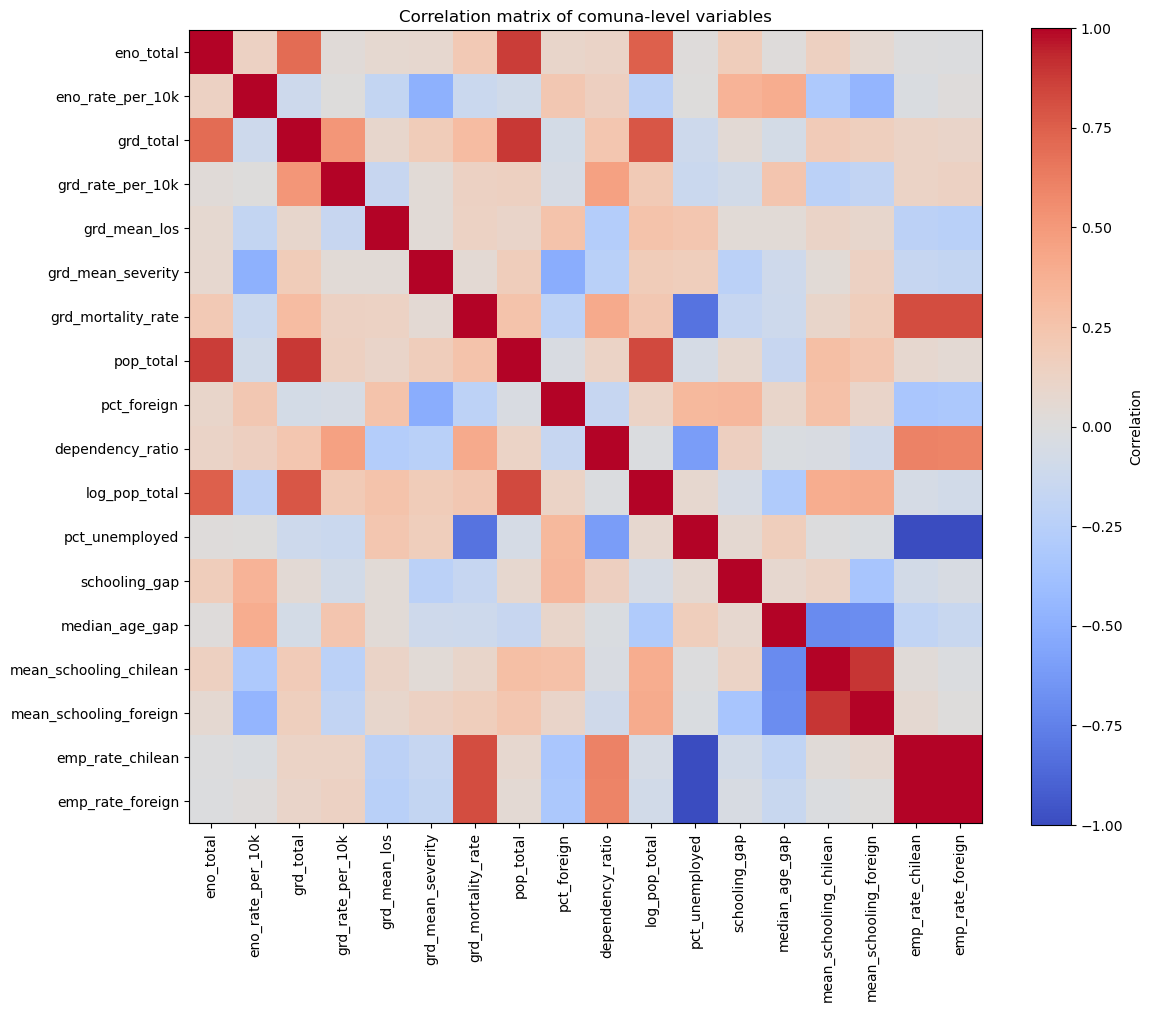

In [18]:
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation matrix of comuna-level variables")
plt.tight_layout()
plt.show()

### **1.2 Bivariate scatter plots**

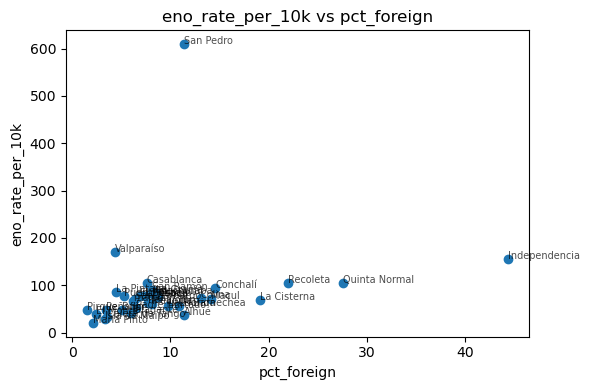

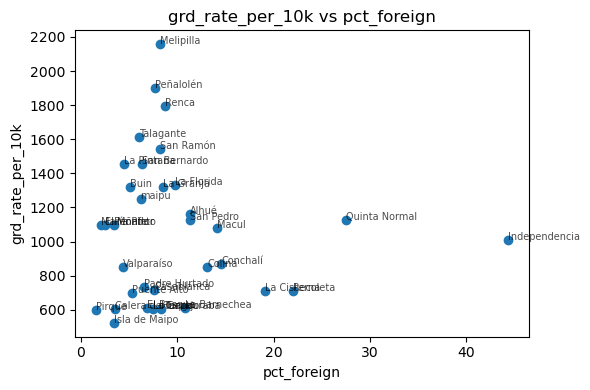

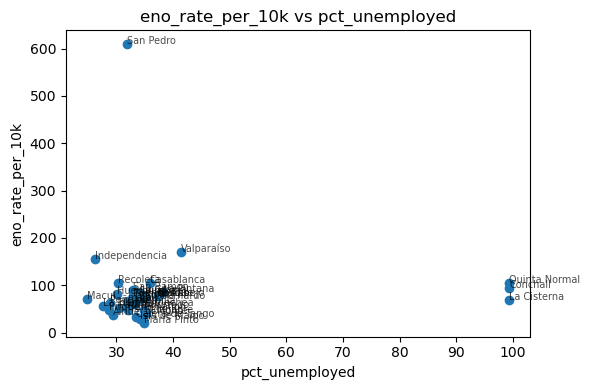

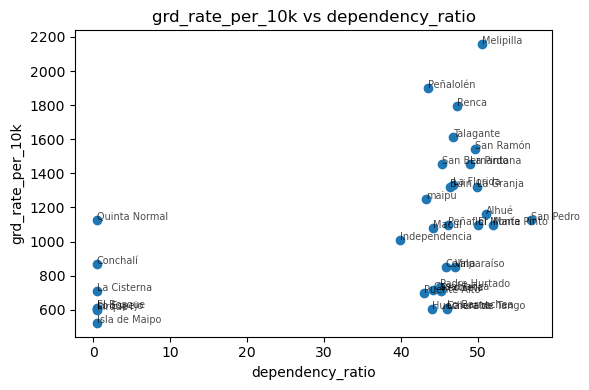

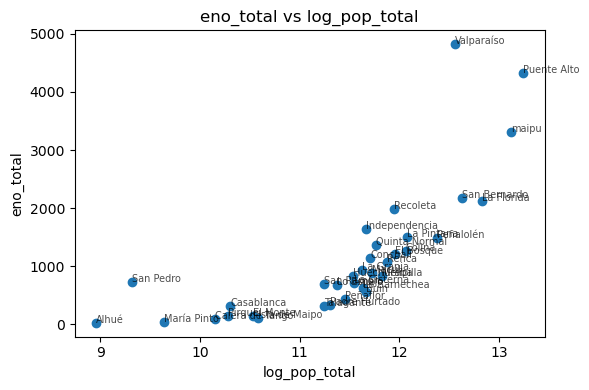

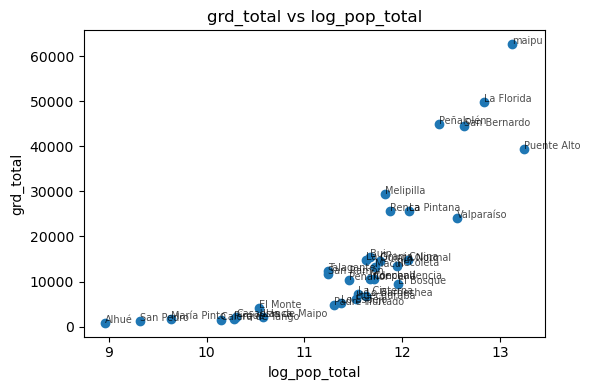

In [19]:
pairs = [
    ("pct_foreign", "eno_rate_per_10k"),
    ("pct_foreign", "grd_rate_per_10k"),
    ("pct_unemployed", "eno_rate_per_10k"),
    ("dependency_ratio", "grd_rate_per_10k"),
    ("log_pop_total", "eno_total"),
    ("log_pop_total", "grd_total")]

for x, y in pairs:
    plt.figure(figsize=(6, 4))
    plt.scatter(analytical_df[x], analytical_df[y])
    
    for _, row in analytical_df.iterrows():
        plt.text(row[x], row[y], row["nombre_comuna"], fontsize=7, alpha=0.7)
    
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

Los scatter plots sirven para pasar de una lectura global de correlaciones a una lectura más territorial. Acá lo importante no era solo ver si la nube subía o bajaba, sino identificar si la relación era más o menos lineal, si algunas comunas se separaban del patrón general y si había casos donde una covariable parecía explicar bien un outcome en unas comunas pero no en otras. Eso es clave porque con solo **34 comunas** cada punto pesa bastante, y un par de observaciones extremas pueden cambiar mucho la pendiente visual. 

En general, estos gráficos ayudan a justificar dos cosas que luego se ven en los modelos: primero, que los conteos sin ajustar están muy influidos por tamaño poblacional; y segundo, que varias relaciones con tasas y covariables sociales existen, pero son bastante más débiles y ruidosas. Justamente por eso después no basta con mirar la recta OLS sobre la nube: hay que modelar mejor, revisar dispersión y mirar residuales.

### **1.3 Outlier and leverage discussion**

En esta parte, lo más relevante es reconocer que no todas las comunas siguen el patrón promedio. En el resto del notebook aparecen comunas claramente influyentes, como **Pirque** y **Calera de Tango**, que destacan por influencia y residuales en el modelo continuo. Aunque eso se calculó formalmente más adelante, ya en los scatter plots tiene sentido pensar que algunas comunas están capturando dinámicas especiales y no solo “ruido”. 

Una explicación plausible para este tipo de outliers es territorial e institucional: hay comunas cuyo uso del sistema de salud no depende solo de su población residente, sino también de derivaciones, cercanía a centros hospitalarios, estructura etaria o diferencias en registro. Por eso, más que “errores”, estas comunas deben leerse como señales de que el comportamiento sanitario agregado no se explica por una sola variable demográfica. 

### **2.1 Preparar variables para modelar**

In [20]:
model_df = analytical_df[
    [
        "codigo_comuna", "nombre_comuna",
        "eno_total", "grd_total",
        "pop_total", "log_pop_total",
        "pct_foreign", "dependency_ratio",
        "pct_unemployed", "schooling_gap", "median_age_gap"]].copy()

model_df.info()
model_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   codigo_comuna     34 non-null     int64  
 1   nombre_comuna     34 non-null     object 
 2   eno_total         34 non-null     int64  
 3   grd_total         34 non-null     int64  
 4   pop_total         34 non-null     int64  
 5   log_pop_total     34 non-null     float64
 6   pct_foreign       34 non-null     float64
 7   dependency_ratio  34 non-null     float64
 8   pct_unemployed    34 non-null     float64
 9   schooling_gap     34 non-null     float64
 10  median_age_gap    34 non-null     float64
dtypes: float64(6), int64(4), object(1)
memory usage: 3.1+ KB


,codigo_comuna,nombre_comuna,eno_total,grd_total,pop_total,log_pop_total,pct_foreign,dependency_ratio,pct_unemployed,schooling_gap,median_age_gap
0,5101,Valparaíso,4821,24180,284938,12.560027,4.320000,46.980000,41.450000,-0.500000,6.7
1,5102,Casablanca,312,2134,29876,10.304811,7.590000,44.210000,35.900000,0.500000,5.8
2,13104,Conchalí,1134,10561,121587,11.708385,14.545963,0.478603,99.319461,-0.658586,5.0
3,13105,El Bosque,1212,9517,155257,11.952837,6.860882,0.497001,35.020637,-1.142156,6.0
4,13107,Huechuraba,832,6170,101808,11.530844,8.280000,44.000000,30.140000,-1.350000,1.0


### **2.2 Modelo Poisson para eno_total**

#### Poisson regression para ENO

El modelo Poisson para `eno_total` se ajustó usando `log(pop_total)` como **offset**, que era lo correcto dado que estamos modelando conteos comunales y no probabilidades individuales. Bajo esta especificación, todos los coeficientes aparecen positivos salvo `schooling_gap`, y casi todos salen altamente significativos: `pct_foreign`, `dependency_ratio`, `pct_unemployed`, `schooling_gap` y `median_age_gap` muestran z muy altos y p-valores prácticamente nulos. A primera vista, eso podría sugerir asociaciones fuertes y bastante estables.

El problema es que esa aparente claridad depende de una suposición muy exigente del Poisson: que la varianza sea parecida a la media. Como eso después no se cumple ni de cerca, este modelo sirve más como línea base que como resultado final. Igual deja algo útil: muestra la dirección inicial de los efectos y confirma que el tamaño poblacional tenía que entrar como offset sí o sí. 

In [21]:
poisson_eno = smf.glm(
    formula="eno_total ~ pct_foreign + dependency_ratio + pct_unemployed + schooling_gap + median_age_gap",
    data=model_df,
    family=sm.families.Poisson(),
    offset=model_df["log_pop_total"]).fit()

print(poisson_eno.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   34
Model:                            GLM   Df Residuals:                       28
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2263.1
Date:                Sun, 03 May 2026   Deviance:                       4242.9
Time:                        19:17:18   Pearson chi2:                 4.68e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -5.5310      0.039  

In [22]:
pearson_chi2_eno = sum(poisson_eno.resid_pearson**2)
dispersion_eno = pearson_chi2_eno / poisson_eno.df_resid

print("Pearson chi2:", pearson_chi2_eno)
print("Dispersion ratio:", dispersion_eno)

Pearson chi2: 4684.681353206459
Dispersion ratio: 167.3100483288021


El chequeo de sobre-dispersión fue decisivo. El estadístico de dispersión para ENO dio **167.31**, muy por encima de 1. Eso significa que la varianza observada entre comunas es muchísimo mayor que la que asumiría un Poisson estándar, por lo que los errores estándar del modelo Poisson quedan subestimados y la significancia aparente se vuelve poco confiable. 

En términos prácticos, este resultado justifica pasar a un modelo Negative Binomial. No era un ajuste opcional ni cosmético: era necesario para no sobreinterpretar coeficientes que el Poisson estaba presentando con demasiada seguridad. 

### **2.3 Negative Binomial para eno_total**

#### ENO: Overdispersion and Negative Binomial

En este paso revisamos si el modelo Poisson era una buena especificación para ENO. La idea es simple: si la dispersión es muy superior a 1, entonces el Poisson está imponiendo una estructura demasiado rígida y probablemente esté subestimando los errores estándar. Si eso pasa, conviene pasar a Negative Binomial.

In [23]:
nb_eno = smf.glm(
    formula="eno_total ~ pct_foreign + dependency_ratio + pct_unemployed + schooling_gap + median_age_gap",
    data=model_df,
    family=sm.families.NegativeBinomial(),
    offset=model_df["log_pop_total"]).fit()

print(nb_eno.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   34
Model:                            GLM   Df Residuals:                       28
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -259.00
Date:                Sun, 03 May 2026   Deviance:                       8.4486
Time:                        19:17:18   Pearson chi2:                     9.52
No. Iterations:                    14   Pseudo R-squ. (CS):             0.2150
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -5.1843      0.937  

c:\Users\gusta\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Cuando se refitó el modelo con Negative Binomial, la historia cambió harto. El AIC bajó fuertemente y el ajuste se volvió mucho más razonable, pero al mismo tiempo los coeficientes dejaron de verse “claramente significativos”. Por ejemplo, `pct_foreign` quedó en **0.0172**, `dependency_ratio` en **0.0049**, `schooling_gap` en **0.3633** y `median_age_gap` en **0.0727**, pero todos con intervalos amplios que incluyen cero. En otras palabras, la señal inicial del Poisson seguía más o menos en la misma dirección, pero con mucha menos certeza.

Ese cambio importa mucho. La conclusión no es que “no haya nada”, sino que con este N comunal y esta variabilidad entre comunas, la evidencia es más incierta de lo que el Poisson hacía parecer. Por eso, entre los dos modelos, el Negative Binomial es el que tiene más sentido reportar como resultado principal para ENO. 

### **2.4 Comparar ajuste**

In [24]:
print("Poisson ENO AIC:", poisson_eno.aic)
print("NB ENO AIC:", nb_eno.aic)

Poisson ENO AIC: 4538.115579433696
NB ENO AIC: 529.9933190595489


### **2.5 IRR para ENO**

In [25]:
irr_eno = np.exp(nb_eno.params)
ci_eno = np.exp(nb_eno.conf_int())

irr_eno_table = ci_eno.copy()
irr_eno_table.columns = ["CI_low", "CI_high"]
irr_eno_table["IRR"] = irr_eno
irr_eno_table

,CI_low,CI_high,IRR
Intercept,0.000893,0.035183,0.005604
pct_foreign,0.971726,1.065165,1.017373
dependency_ratio,0.982071,1.028216,1.004878
pct_unemployed,0.976785,1.023527,0.999883
schooling_gap,0.695725,2.972316,1.438024
median_age_gap,0.977964,1.182466,1.075365


La dispersión en ENO resultó muy alta, así que el Poisson no era un modelo adecuado para reportar como resultado principal. Al pasar a Negative Binomial, el ajuste mejora y la lectura se vuelve más realista: la dirección de varios coeficientes se mantiene, pero la incertidumbre aumenta bastante. Eso importa, porque muestra que el Poisson estaba dando una sensación de precisión mayor a la que realmente permiten los datos.

Entonces el mensaje principal no es que “no haya relación”, sino que con este nivel de heterogeneidad comunal los efectos no están tan definidos como parecía al comienzo. Por eso, para ENO el modelo que tiene más sentido reportar es el Negative Binomial.

### **2.6 Modelo Poisson para grd_total**

#### GRD: Poisson regression

Ahora repetimos la misma lógica para `grd_total`. Igual que en ENO, usamos `log(pop_total)` como offset para ajustar por el tamaño de la comuna y evitar que las diferencias de población distorsionen la comparación entre territorios.

Este modelo Poisson sirve como punto de partida para entender cómo se relaciona la carga hospitalaria con las covariables comunales. Pero, otra vez, no conviene leerlo como resultado final antes de revisar la dispersión.

In [26]:
poisson_grd = smf.glm(
    formula="grd_total ~ pct_foreign + dependency_ratio + pct_unemployed + schooling_gap + median_age_gap",
    data=model_df,
    family=sm.families.Poisson(),
    offset=model_df["log_pop_total"]).fit()

print(poisson_grd.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              grd_total   No. Observations:                   34
Model:                            GLM   Df Residuals:                       28
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -24718.
Date:                Sun, 03 May 2026   Deviance:                       49063.
Time:                        19:17:18   Pearson chi2:                 4.96e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.2525      0.011  

El Poisson para GRD entrega una primera aproximación del patrón comunal del outcome, pero todavía no es suficiente para cerrar conclusiones. Dado que la hospitalización suele mostrar mucha heterogeneidad territorial, era esperable que el Poisson quedara corto. Por eso, lo siguiente es verificar formalmente la sobre-dispersión.

### **Overdispersion para GRD**

In [27]:
pearson_chi2_grd = sum(poisson_grd.resid_pearson**2)
dispersion_grd = pearson_chi2_grd / poisson_grd.df_resid

print("Pearson chi2:", pearson_chi2_grd)
print("Dispersion ratio:", dispersion_grd)

Pearson chi2: 49589.50201233317
Dispersion ratio: 1771.0536432976132


### **2.7 Negative Binomial para grd_total**

In [28]:
nb_grd = smf.glm(
    formula="grd_total ~ pct_foreign + dependency_ratio + pct_unemployed + schooling_gap + median_age_gap",
    data=model_df,
    family=sm.families.NegativeBinomial(),
    offset=model_df["log_pop_total"]).fit()

print(nb_grd.summary())

c:\Users\gusta\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              grd_total   No. Observations:                   34
Model:                            GLM   Df Residuals:                       28
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -346.55
Date:                Sun, 03 May 2026   Deviance:                       2.9488
Time:                        19:17:18   Pearson chi2:                     3.17
No. Iterations:                     7   Pseudo R-squ. (CS):            0.06107
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.3433      0.936  

### **Comparar ajuste**

#### GRD: Overdispersion and Negative Binomial

En GRD hacemos el mismo chequeo que en ENO. Si la dispersión vuelve a ser muy alta, entonces el Poisson no está capturando bien la variabilidad entre comunas y corresponde usar Negative Binomial como modelo principal.

In [29]:
print("Poisson GRD AIC:", poisson_grd.aic)
print("NB GRD AIC:", nb_grd.aic)

Poisson GRD AIC: 49448.1207067559
NB GRD AIC: 705.1064401079857


### **IRR para GRD**

In [30]:
irr_grd = np.exp(nb_grd.params)
ci_grd = np.exp(nb_grd.conf_int())

irr_grd_table = ci_grd.copy()
irr_grd_table.columns = ["CI_low", "CI_high"]
irr_grd_table["IRR"] = irr_grd
irr_grd_table

,CI_low,CI_high,IRR
Intercept,0.005644,0.221018,0.035320
pct_foreign,0.956979,1.048950,1.001910
dependency_ratio,0.992793,1.039348,1.015804
pct_unemployed,0.982902,1.029890,1.006121
schooling_gap,0.407792,1.739503,0.842232
median_age_gap,0.935954,1.131334,1.029017


En GRD la sobre-dispersión fue incluso más fuerte que en ENO, así que el Poisson definitivamente no era suficiente. El Negative Binomial entrega una lectura mucho más creíble del outcome, aunque también deja claro que varios efectos son bastante inciertos una vez corregidos los errores estándar.

Más que destacar un coeficiente aislado, lo que sobresale acá es la fuerte heterogeneidad comunal de la carga hospitalaria. Eso sugiere que el territorio importa, pero de una forma más compleja de lo que un modelo Poisson simple alcanzaba a mostrar. Por eso, igual que en ENO, el modelo que conviene reportar como principal es el Negative Binomial.

### **3.1 Preparar base**

#### Outcome continuo elegido

Para la parte continua se eligió `grd_mean_los`, es decir, la **estadía media hospitalaria**. Tiene sentido porque no mide solo cuántos egresos hay, sino algo más cercano a la intensidad o complejidad promedio de la atención hospitalaria. Eso la hace interesante como outcome complementario a los modelos de conteo. 

In [31]:
ols_df = analytical_df[
    [
        "codigo_comuna", "nombre_comuna",
        "grd_mean_los",
        "pct_foreign", "dependency_ratio",
        "pct_unemployed", "schooling_gap", "median_age_gap",
        "log_pop_total"]].copy()

ols_df.info()
ols_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   codigo_comuna     34 non-null     int64  
 1   nombre_comuna     34 non-null     object 
 2   grd_mean_los      34 non-null     float64
 3   pct_foreign       34 non-null     float64
 4   dependency_ratio  34 non-null     float64
 5   pct_unemployed    34 non-null     float64
 6   schooling_gap     34 non-null     float64
 7   median_age_gap    34 non-null     float64
 8   log_pop_total     34 non-null     float64
dtypes: float64(7), int64(1), object(1)
memory usage: 2.5+ KB


,codigo_comuna,nombre_comuna,grd_mean_los,pct_foreign,dependency_ratio,pct_unemployed,schooling_gap,median_age_gap,log_pop_total
0,5101,Valparaíso,5.600000,4.320000,46.980000,41.450000,-0.500000,6.7,12.560027
1,5102,Casablanca,4.800000,7.590000,44.210000,35.900000,0.500000,5.8,10.304811
2,13104,Conchalí,6.366632,14.545963,0.478603,99.319461,-0.658586,5.0,11.708385
3,13105,El Bosque,7.223915,6.860882,0.497001,35.020637,-1.142156,6.0,11.952837
4,13107,Huechuraba,6.090000,8.280000,44.000000,30.140000,-1.350000,1.0,11.530844


### **3.2 Correr OLS**

In [32]:
ols_los = smf.ols(
    formula="grd_mean_los ~ pct_foreign + dependency_ratio + pct_unemployed + schooling_gap + median_age_gap + log_pop_total",
    data=ols_df).fit()

print(ols_los.summary())

                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.9440
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.480
Time:                        19:17:18   Log-Likelihood:                -34.476
No. Observations:                  34   AIC:                             82.95
Df Residuals:                      27   BIC:                             93.64
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.8321      1.670  

#### Linear regression (OLS)

Ajustamos un modelo OLS usando `grd_mean_los` como outcome y las mismas covariables comunales que veníamos trabajando. El resultado general fue más bien débil: el modelo obtuvo un **R² de 0.173** y un **R² ajustado de -0.010**, así que estas variables explican solo una parte pequeña de la variación en la estadía media entre comunas. En la práctica, eso sugiere que el perfil demográfico y social de la comuna podría influir, pero claramente no alcanza por sí solo para describir bien este outcome.

Además, ninguno de los coeficientes principales quedó especialmente bien definido una vez que se mira la incertidumbre. Entonces, más que hablar de efectos claros, lo más honesto es decir que el outcome continuo parece bastante más difícil de modelar que los conteos ajustados por población.

### **3.3 Predicciones y residuales**

#### Diagnostics

Los diagnósticos del OLS no muestran una catástrofe, pero tampoco dejan un modelo especialmente sólido. El Durbin-Watson quedó en **1.937** y los test de normalidad de residuos no se ven especialmente malos, así que no hay una violación brutal a primera vista. Aun así, el problema principal no es tanto la forma de los residuos, sino el bajo poder explicativo del modelo y la sensibilidad a algunas comunas concretas.

Eso se ve claro con la influencia: **Pirque** tiene el mayor `cooks_d` (**0.766**) y también un `hat_diag` alto (**0.432**), mientras **Calera de Tango** muestra un residuo considerable (**1.826**) y también influencia no menor. Entonces, aunque OLS puede servir como aproximación descriptiva, no parece una base especialmente robusta para hacer afirmaciones fuertes. Si hubiera que seguir, lo razonable sería probar errores robustos, transformar el outcome o escoger otro indicador continuo más estable. 

In [33]:
ols_df["pred_los"] = ols_los.fittedvalues
ols_df["resid_los"] = ols_los.resid

ols_df[["codigo_comuna", "nombre_comuna", "grd_mean_los", "pred_los", "resid_los"]].head()

,codigo_comuna,nombre_comuna,grd_mean_los,pred_los,resid_los
0,5101,Valparaíso,5.600000,5.911193,-0.311193
1,5102,Casablanca,4.800000,5.585185,-0.785185
2,13104,Conchalí,6.366632,6.294505,0.072127
3,13105,El Bosque,7.223915,6.226316,0.997599
4,13107,Huechuraba,6.090000,5.681141,0.408859


### **3.4 Residuals vs fitted**

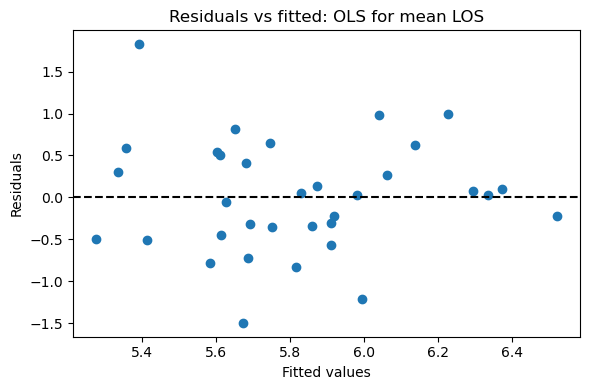

In [34]:
plt.figure(figsize=(6, 4))
plt.scatter(ols_df["pred_los"], ols_df["resid_los"])
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted: OLS for mean LOS")
plt.tight_layout()
plt.show()

#### Residuals vs fitted

Este gráfico sirve para ver si los residuos del modelo se distribuyen de manera relativamente aleatoria alrededor de 0 o si aparece algún patrón claro. Si los puntos formaran una curva, un embudo o una estructura muy marcada, eso sería una señal de que el modelo lineal no está capturando bien la relación entre las variables.

En este caso, los residuos se ven bastante dispersos alrededor de la línea horizontal en 0 y no aparece una forma demasiado clara. Eso juega a favor del modelo, porque sugiere que no hay una no linealidad brutal ni una mala especificación demasiado evidente. Igual, sí se notan algunos puntos más alejados, tanto positivos como negativos, lo que ya anticipa que hay comunas donde el ajuste no es tan bueno como en el resto.

### **3.5 QQ plot**

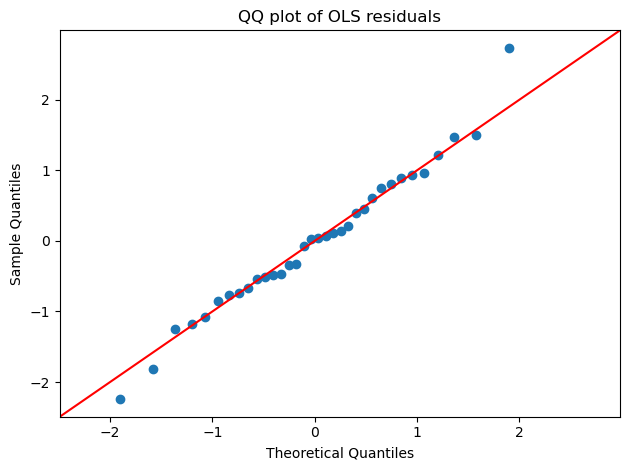

In [35]:
sm.qqplot(ols_los.resid, line="45", fit=True)
plt.title("QQ plot of OLS residuals")
plt.tight_layout()
plt.show()

#### QQ plot

El QQ plot se usa para revisar si los residuos del modelo siguen una distribución aproximadamente normal. Esto importa porque, aunque OLS puede seguir funcionando como aproximación descriptiva, la normalidad de residuos ayuda a que la inferencia clásica sea más defendible.

Acá la mayoría de los puntos sigue bastante bien la recta, sobre todo en la zona central, así que no parece haber un problema grave de normalidad. Lo que sí se observa es una desviación algo mayor en los extremos, especialmente en la cola superior. Eso sugiere que el supuesto de normalidad es razonable, pero no perfecto. En otras palabras, el modelo no se cae por este lado, aunque tampoco conviene sobredimensionar la precisión de los resultados.

### **3.6 Scale-location plot simple**

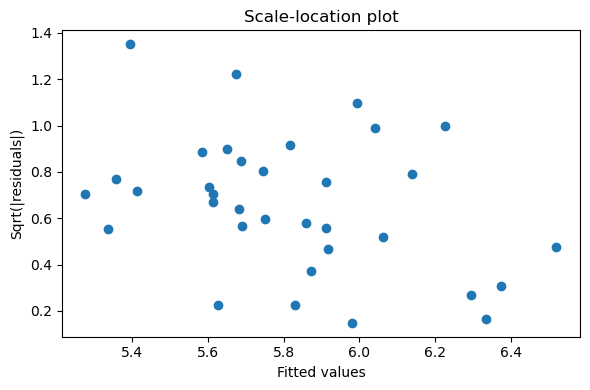

In [36]:
sqrt_abs_resid = np.sqrt(np.abs(ols_df["resid_los"]))

plt.figure(figsize=(6, 4))
plt.scatter(ols_df["pred_los"], sqrt_abs_resid)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|residuals|)")
plt.title("Scale-location plot")
plt.tight_layout()
plt.show()

#### Scale-location plot simple

Este gráfico ayuda a mirar si la varianza de los residuos se mantiene más o menos constante a lo largo de los valores ajustados. Si apareciera una tendencia muy clara, por ejemplo que los puntos se abren mucho a medida que suben los fitted values, eso sería una señal de heterocedasticidad.

En este caso no se observa un patrón extremadamente marcado. La dispersión cambia un poco entre zonas, pero no se ve un embudo muy evidente ni una tendencia sistemática demasiado fuerte. Eso sugiere que la homocedasticidad es aceptable como aproximación. De todos modos, hay algunos puntos con residuos relativamente altos, así que el ajuste sigue siendo sensible a ciertas comunas específicas.

### **3.7 Ver comunas más influyentes / residuales grandes**

In [37]:
ols_df["abs_resid"] = np.abs(ols_df["resid_los"])
ols_df.sort_values("abs_resid", ascending=False)[
    ["codigo_comuna", "nombre_comuna", "grd_mean_los", "pred_los", "resid_los", "abs_resid"]]

,codigo_comuna,nombre_comuna,grd_mean_los,pred_los,resid_los,abs_resid
24,13403,Calera de Tango,7.220000,5.393962,1.826038,1.826038
20,13202,Pirque,4.176776,5.673121,-1.496344,1.496344
19,13201,Puente Alto,4.784390,5.993142,-1.208752,1.208752
3,13105,El Bosque,7.223915,6.226316,0.997599,0.997599
13,13119,maipu,7.020000,6.040284,0.979716,0.979716
25,13501,Melipilla,4.980000,5.816296,-0.836296,0.836296
29,13601,Talagante,6.460000,5.650435,0.809565,0.809565
1,5102,Casablanca,4.800000,5.585185,-0.785185,0.785185
18,13131,San Ramón,4.966448,5.687859,-0.721411,0.721411
17,13128,Renca,6.392185,5.746744,0.645441,0.645441


Esta tabla muestra las comunas donde más se equivoca el modelo, es decir, donde la diferencia entre el valor observado y el valor predicho es más grande. Esto es importante porque permite identificar casos que pueden estar empujando el ajuste o que no siguen el patrón general del modelo.

Acá destaca primero **Calera de Tango**, con el mayor residuo absoluto, lo que significa que el modelo subestima bastante su `grd_mean_los`. También aparece **Pirque** con un residuo negativo grande, o sea, ahí el modelo sobreestima la estadía media. Más abajo se repiten comunas como **Puente Alto**, **El Bosque**, **Maipú** y **Melipilla**, que también se apartan del ajuste esperado.

La lectura de fondo es que el modelo logra capturar una parte del patrón general, pero no describe igual de bien a todas las comunas. Algunas parecen responder a dinámicas locales que no están bien recogidas por las covariables incluidas. Por eso, esta tabla no solo muestra “errores”: también marca dónde sería más razonable sospechar que faltan variables relevantes o que el comportamiento comunal es más particular.

### **3.8 Opcional: influencia tipo Cook’s distance**

Esta tabla es un complemento para la revisión de residuos, ya que muestra qué comunas no solo tienen errores grandes, sino también cuáles influyen más en el ajuste del modelo. En este caso, **Pirque** destaca como la comuna más influyente, y **Calera de Tango** también aparece con bastante peso.

Esto sugiere que el modelo OLS es sensible a unas pocas comunas específicas. Por eso, aunque el ajuste puede servir como aproximación descriptiva, los resultados no son completamente estables.

In [38]:
influence = ols_los.get_influence()
summary_influence = influence.summary_frame()

ols_df["cooks_d"] = summary_influence["cooks_d"].values
ols_df["hat_diag"] = summary_influence["hat_diag"].values

ols_df.sort_values("cooks_d", ascending=False)[
    ["codigo_comuna", "nombre_comuna", "cooks_d", "hat_diag", "resid_los"]]


,codigo_comuna,nombre_comuna,cooks_d,hat_diag,resid_los
20,13202,Pirque,0.765865,0.432316,-1.496344
24,13403,Calera de Tango,0.241811,0.187677,1.826038
3,13105,El Bosque,0.135279,0.277944,0.997599
19,13201,Puente Alto,0.084166,0.159574,-1.208752
1,5102,Casablanca,0.081901,0.274348,-0.785185
13,13119,maipu,0.067247,0.183280,0.979716
10,13115,Lo Barnechea,0.061848,0.415478,-0.446619
28,13505,San Pedro,0.043981,0.311057,-0.513030
11,13116,Lo Espejo,0.042549,0.243913,0.625387
30,13602,El Monte,0.029815,0.208435,0.592878


## PARTE 4 ##


### **Part 4: Ecological Fallacy (1 pt)**

#### **Ecological fallacy**

Todo lo que hicimos en esta tarea es ecológico porque la unidad de análisis es la **comuna**, no la persona. Eso significa que una asociación entre `pct_foreign` y `eno_rate_per_10k` no autoriza a decir que una persona extranjera tenga más o menos probabilidad individual de ser notificada. Lo único que puede decirse es que las comunas con cierta composición demográfica tienden a mostrar ciertos niveles agregados del outcome. Esa diferencia parece obvia, pero es exactamente la falacia ecológica que la pauta pide discutir.

Un ejemplo concreto aparece en el modelo de ENO. En el Negative Binomial, `pct_foreign` tiene coeficiente positivo (**0.0172**), pero con alta incertidumbre y sin significancia clara. Sería un error traducir eso como “los extranjeros tienen mayor riesgo individual de ENO”. Esa sería una mala lectura por dos motivos: primero, porque el modelo no es individual; segundo, porque incluso a nivel comunal la evidencia no es precisa. Lo correcto es decir que, en esta muestra de comunas, el porcentaje de población extranjera no muestra una asociación robusta con el conteo de ENO una vez ajustado por población y por otras covariables.

Aun así, las asociaciones ecológicas sí sirven para planificación pública. Por ejemplo, la sobre-dispersión extrema en ENO (**167.31**) y GRD (**1771.1**) muestra que las comunas son mucho más heterogéneas de lo que asumiría un modelo simple. Eso ya es información útil para salud pública, porque sugiere que no basta con repartir recursos usando una regla uniforme por población. Algunas comunas concentran mucha más carga, o se desvían mucho de lo esperado, y eso merece atención aunque no diga nada definitivo sobre individuos. 

Otro problema que no resolvimos del todo es el de la **confusión omitida**. Las diferencias comunales en ENO y GRD pueden depender no solo de demografía, sino también de cercanía a hospitales, capacidad de diagnóstico, calidad del registro, flujos intercomunales o incluso autocorrelación espacial. En el futuro, eso se podría abordar agregando variables institucionales, usando modelos espaciales o incorporando errores robustos y análisis de sensibilidad. Entonces, el valor de esta tarea no está en probar causalidad individual, sino en identificar patrones territoriales plausibles y comunas donde vale la pena mirar más de cerca. 

## PARTE 5 ##

### **5.1 Cargar shapefile y unirlo a la base analítica**

#### 5.1 Predicted-rate map

El mapa de tasas predichas resume lo que el modelo espera para cada comuna una vez combinadas las covariables y el offset poblacional. En la tabla mostrada, por ejemplo, **Independencia** aparece con una tasa ENO predicha de **175.83 por 10.000**, mientras **San Ramón** destaca en GRD con una tasa predicha de **1526.77 por 10.000**. Eso sugiere que los dos outcomes no se distribuyen igual en el territorio y que cada uno responde a una combinación distinta de factores comunales.

In [39]:
comunas_gdf = gpd.read_file("Comunas/comunas.shp")
comunas_gdf["codigo_comuna"] = comunas_gdf["cod_comuna"].astype(int)

map_df = comunas_gdf.merge(analytical_df, on="codigo_comuna", how="inner")

print(map_df.shape)
map_df[["codigo_comuna", "Comuna", "nombre_comuna"]]

(34, 48)


,codigo_comuna,Comuna,nombre_comuna
0,13131,San Ramón,San Ramón
1,13108,Independencia,Independencia
2,13109,La Cisterna,La Cisterna
3,13122,Peñalolén,Peñalolén
4,13403,Calera de Tango,Calera de Tango
5,13301,Colina,Colina
6,13202,Pirque,Pirque
7,13201,Puente Alto,Puente Alto
8,13107,Huechuraba,Huechuraba
9,13401,San Bernardo,San Bernardo


### **5.2 Predicciones para ENO y GRD**

#### Residual map

El mapa de residuales sirve para ver dónde el modelo se queda corto o se pasa. Los residuales positivos indican comunas donde el outcome observado fue mayor que el esperado por el modelo, y los negativos indican lo contrario. En GRD, una comuna como **Peñalolén** aparece después como un caso importante de desajuste, lo que sugiere que hay factores locales relevantes que el modelo no está capturando bien. :contentReference[oaicite:25]{index=25}

La utilidad de este mapa no es solo estadística. También sirve para levantar hipótesis territoriales: derivaciones hospitalarias, especialización de servicios, subregistro o características no observadas del sistema local de salud. En ese sentido, los residuales no son “errores” sin más, sino pistas sobre lo que falta explicar. :contentReference[oaicite:26]{index=26}

In [40]:
map_df["pred_eno_count"] = nb_eno.predict(map_df, offset=np.log(map_df["pop_total"]))
map_df["pred_grd_count"] = nb_grd.predict(map_df, offset=np.log(map_df["pop_total"]))

map_df["pred_eno_rate_10k"] = (map_df["pred_eno_count"] / map_df["pop_total"]) * 10000
map_df["pred_grd_rate_10k"] = (map_df["pred_grd_count"] / map_df["pop_total"]) * 10000

map_df[["codigo_comuna", "nombre_comuna","pred_eno_rate_10k", "pred_grd_rate_10k"]].head()

,codigo_comuna,nombre_comuna,pred_eno_rate_10k,pred_grd_rate_10k
0,13131,San Ramón,88.139721,1526.767593
1,13108,Independencia,175.828195,931.092341
2,13109,La Cisterna,86.852559,876.179010
3,13122,Peñalolén,84.042543,1055.313275
4,13403,Calera de Tango,83.628325,960.997368


### **5.3 Residuales para ENO y GRD**

### 5.3 Coefficient plot

El coefficient plot ayuda a comparar los tres modelos con una sola visualización. En tu tabla de coeficientes se ve bien que, para los modelos NB de ENO y GRD, casi todos los intervalos de confianza cruzan cero, especialmente en `pct_foreign`, `dependency_ratio`, `pct_unemployed` y `schooling_gap`. Eso refuerza la idea de que, una vez corregida la sobre-dispersión, la evidencia para efectos comunales puntuales es bastante más incierta de lo que sugerían los modelos Poisson. 

Lo valioso del gráfico no es adornar, sino obligar a una lectura más honesta: mirar dirección, magnitud e incertidumbre al mismo tiempo. En esta tarea eso importa mucho, porque con **34 comunas** y alta heterogeneidad territorial es fácil sobrerreaccionar a un p-valor o a un coeficiente aislado. :contentReference[oaicite:28]{index=28}

In [41]:
map_df["resid_eno"] = map_df["eno_total"] - map_df["pred_eno_count"]
map_df["resid_grd"] = map_df["grd_total"] - map_df["pred_grd_count"]

map_df[["codigo_comuna", "nombre_comuna", "resid_eno", "resid_grd"]]

,codigo_comuna,nombre_comuna,resid_eno,resid_grd
0,13131,San Ramón,17.120489,139.260943
1,13108,Independencia,-414.187658,-315.473162
2,13109,La Cisterna,-181.944942,-1700.399818
3,13122,Peñalolén,-500.421243,19961.162725
4,13403,Calera de Tango,-129.176963,-910.678390
5,13301,Colina,27.808578,-758.229225
6,13202,Pirque,55.009187,291.481648
7,13201,Puente Alto,599.324112,-15242.590245
8,13107,Huechuraba,297.127216,-5187.194343
9,13401,San Bernardo,144.196882,13013.573170


### **5.4 Mapa de tasa predicha ENO**

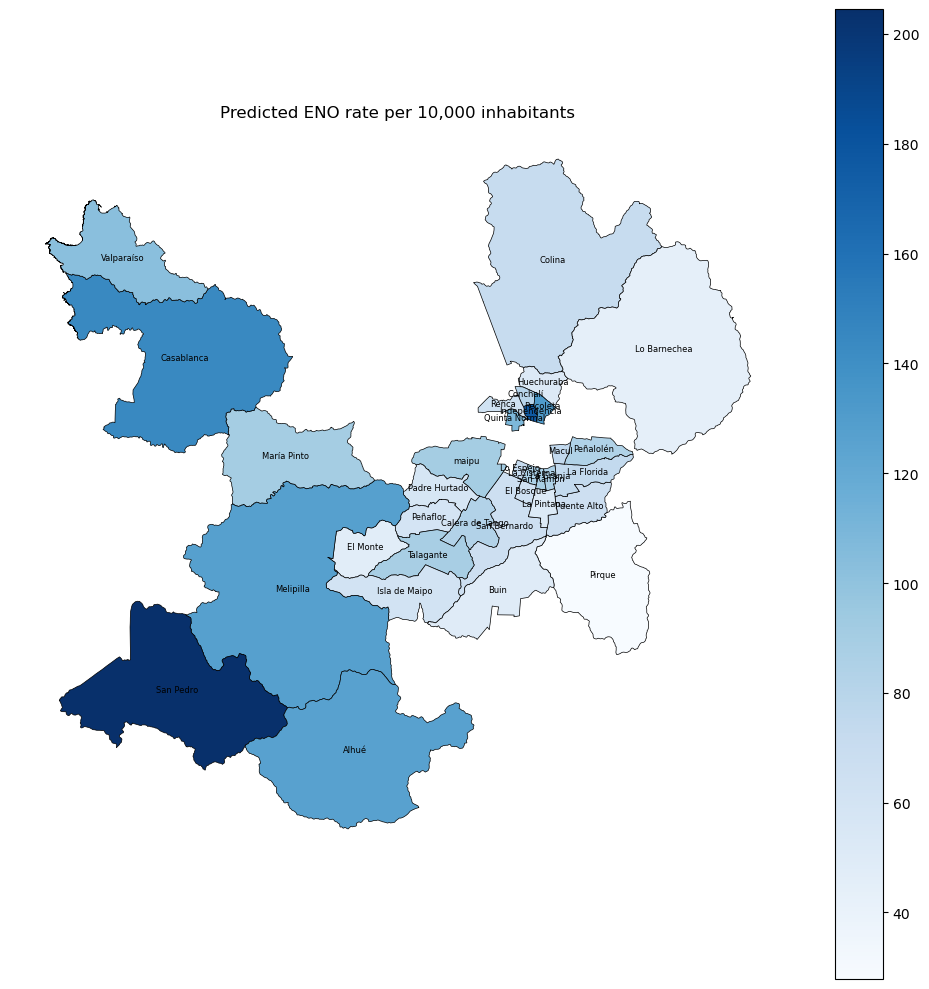

In [42]:
fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="pred_eno_rate_10k",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax)

for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["nombre_comuna"], fontsize=6, ha="center")

ax.set_title("Predicted ENO rate per 10,000 inhabitants")
ax.axis("off")
plt.tight_layout()
plt.show()

Este mapa muestra la **tasa predicha de ENO por 10.000 habitantes** según el modelo. Se observa que las comunas del sector poniente y surponiente, como **San Pedro**, **Alhué**, **Melipilla** y **Casablanca**, concentran los valores predichos más altos, mientras que varias comunas del sector oriente y del centro aparecen con niveles más bajos.

En términos generales, el modelo está asociando una mayor tasa esperada de ENO a comunas más periféricas y una menor tasa a comunas más urbanas y densas del eje central-oriente.

### **5.5 Mapa de residuales ENO**

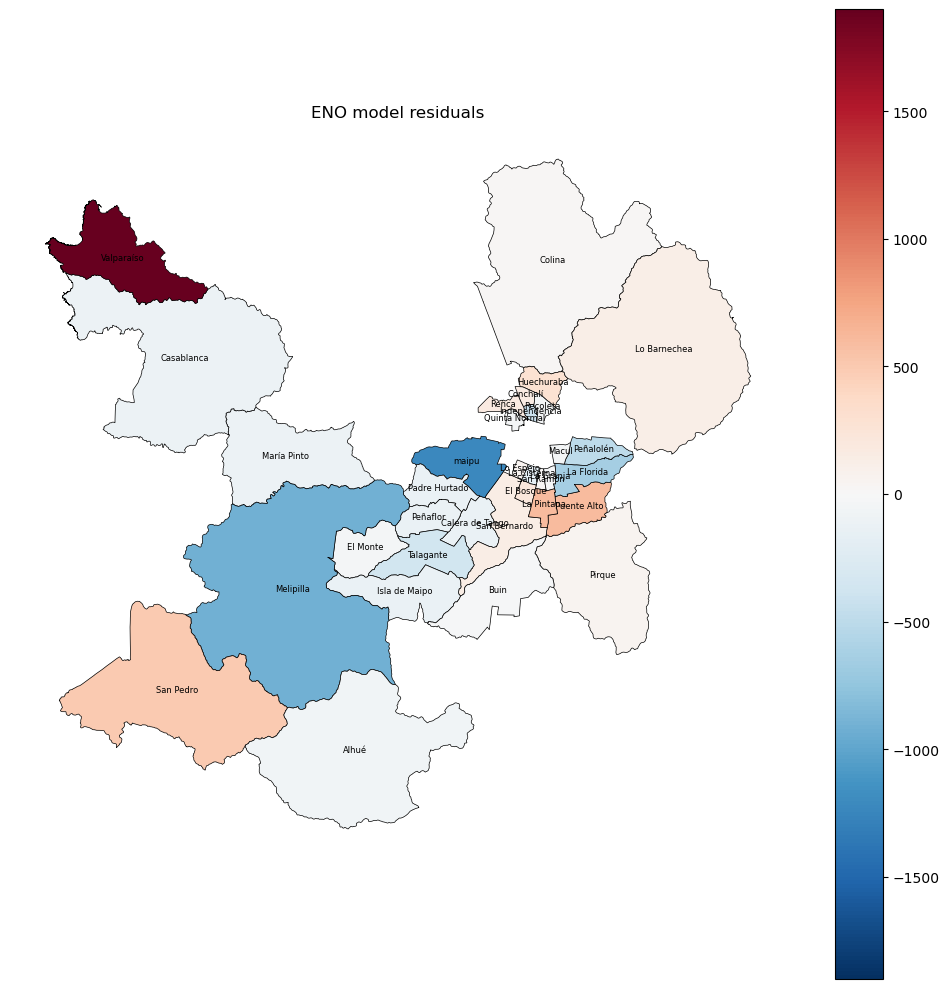

In [43]:
fig, ax = plt.subplots(figsize=(10, 10))

vmax = np.abs(map_df["resid_eno"]).max()

map_df.plot(
    column="resid_eno",
    cmap="RdBu_r",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    vmin=-vmax,
    vmax=vmax)

for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["nombre_comuna"], fontsize=6, ha="center")

ax.set_title("ENO model residuals")
ax.axis("off")
plt.tight_layout()
plt.show()

Este mapa muestra los **residuales del modelo de ENO**, o sea, la diferencia entre lo observado y lo predicho. Los valores positivos indican comunas donde el modelo **subestimó** los casos, mientras que los negativos muestran comunas donde el modelo **sobreestimó**.

Acá destaca con fuerza **Valparaíso** con un residual positivo alto, mientras que comunas como **Maipú** y parte del sector suroriente aparecen con residuales negativos importantes. Esto sugiere que el modelo logra captar parte del patrón general, pero todavía deja comunas donde el ajuste no es bueno y donde probablemente faltan factores locales.

### **5.6 Mapa de tasa predicha GRD**

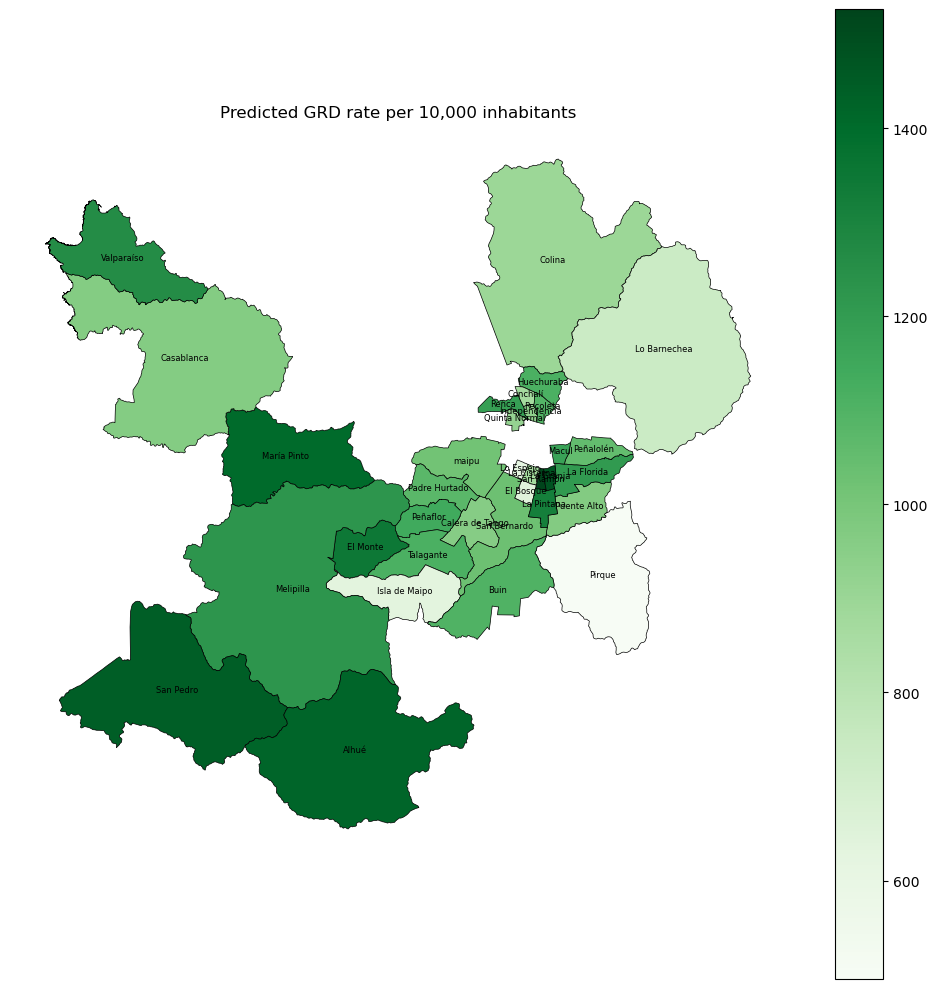

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="pred_grd_rate_10k",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax)

for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["nombre_comuna"], fontsize=6, ha="center")

ax.set_title("Predicted GRD rate per 10,000 inhabitants")
ax.axis("off")
plt.tight_layout()
plt.show()

Este mapa muestra la **tasa predicha de GRD por 10.000 habitantes**. En este caso, las comunas con valores más altos se concentran sobre todo en el sector sur y surponiente, como **San Pedro**, **Alhué**, **Melipilla** y **María Pinto**, mientras que varias comunas del norte y oriente quedan con tasas predichas más bajas.

Comparado con ENO, el patrón de GRD parece más extendido territorialmente, aunque muestra una diferencia clara entre comunas periféricas con valores altos y comunas del eje oriente con valores más bajos.

### **5.7 Mapa de residuales GRD**

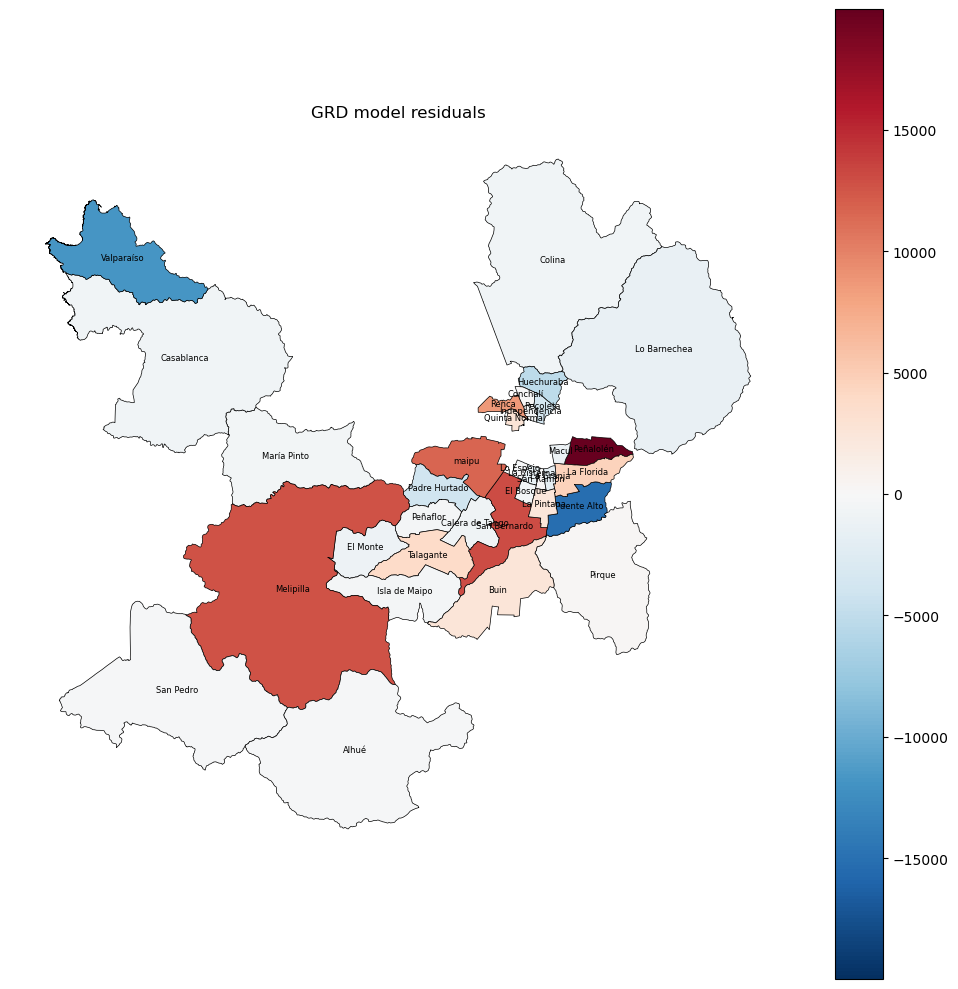

In [45]:
fig, ax = plt.subplots(figsize=(10, 10))

vmax = np.abs(map_df["resid_grd"]).max()

map_df.plot(
    column="resid_grd",
    cmap="RdBu_r",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    vmin=-vmax,
    vmax=vmax)

for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["nombre_comuna"], fontsize=6, ha="center")

ax.set_title("GRD model residuals")
ax.axis("off")
plt.tight_layout()
plt.show()

Este mapa muestra los **residuales del modelo de GRD**. Igual que antes, los valores positivos representan comunas donde el modelo quedó corto, y los negativos comunas donde predijo más de lo observado.

Lo que más resalta acá es que hay comunas con desviaciones bastante grandes, especialmente **Peñalolén** con un residual positivo muy alto, y **La Pintana** con un residual negativo fuerte. También aparecen comunas como **Melipilla** y **Maipú** con residuales positivos importantes.

### **5.8 Mapa del outcome continuo predicho por OLS**

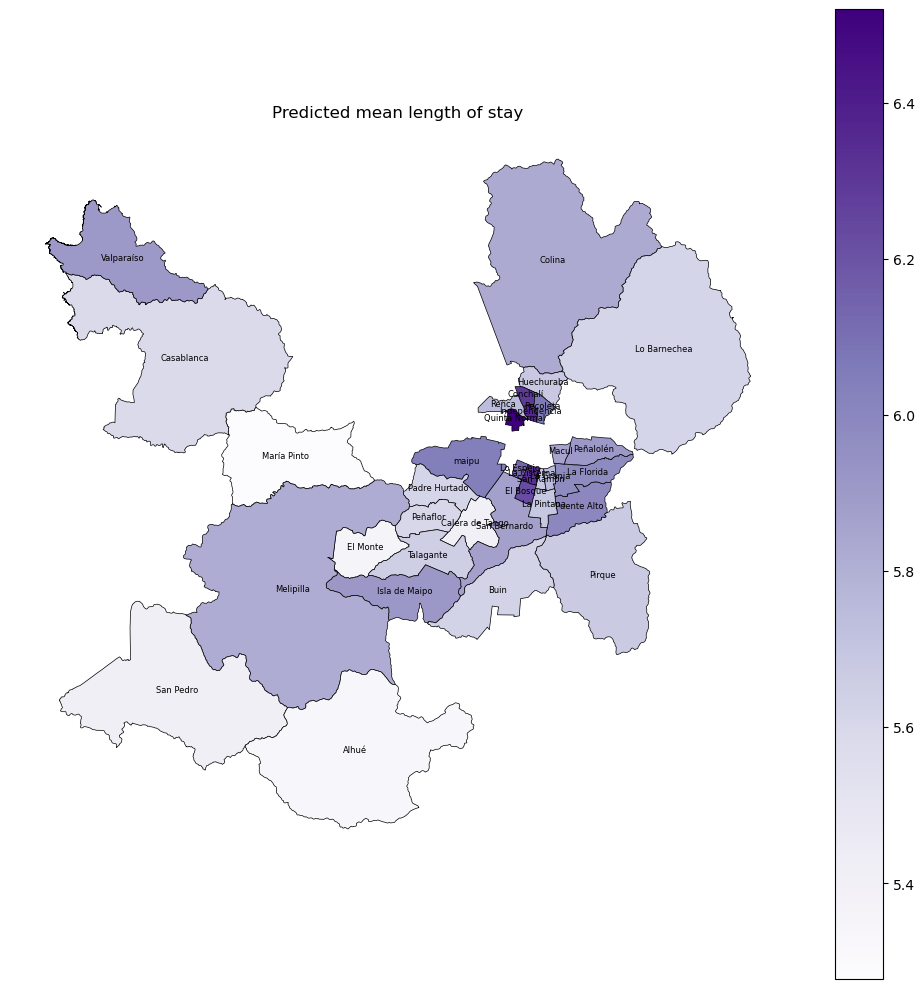

In [46]:
map_df["pred_los"] = ols_los.predict(map_df)
map_df["resid_los"] = map_df["grd_mean_los"] - map_df["pred_los"]

fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="pred_los",
    cmap="Purples",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax)

for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["nombre_comuna"], fontsize=6, ha="center")

ax.set_title("Predicted mean length of stay")
ax.axis("off")
plt.tight_layout()
plt.show()

Este mapa muestra la **estadía media hospitalaria predicha** por el modelo OLS. A diferencia de los mapas de conteo, acá la variación territorial es moderada y los valores predichos se concentran en un rango estrecho.

Se observa que varias comunas del centro y del eje urbano aparecen con valores algo más altos, mientras que comunas más periféricas como **San Pedro**, **Alhué** o **Pirque** quedan con valores más bajos.

### **5.9 Residuales del OLS**

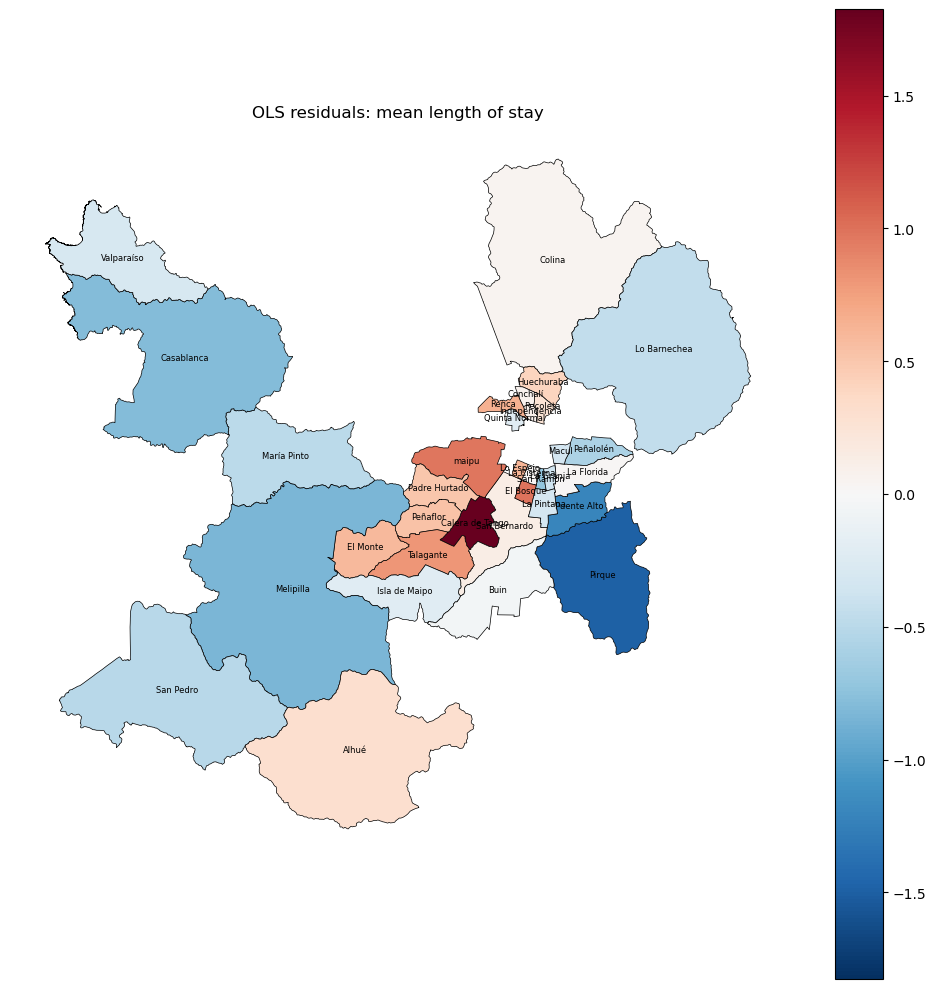

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))

vmax = np.abs(map_df["resid_los"]).max()

map_df.plot(
    column="resid_los",
    cmap="RdBu_r",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    vmin=-vmax,
    vmax=vmax)

for _, row in map_df.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["nombre_comuna"], fontsize=6, ha="center")

ax.set_title("OLS residuals: mean length of stay")
ax.axis("off")
plt.tight_layout()
plt.show()

Este mapa muestra los **residuales del modelo OLS para estadía media hospitalaria**. Los valores positivos indican comunas donde la estadía observada fue mayor que la predicha, y los negativos donde fue menor.

Acá se ve que **Calera de Tango** destaca con un residual positivo alto, mientras que **Pirque** aparece con uno negativo fuerte. También se observan desviaciones en comunas como **Maipú**, **Talagante** y **El Monte**. reforzando la idea de que el modelo OLS logra capturar parte del patrón general, pero sigue siendo sensible a ciertas comunas y no describe igual de bien a todo el territorio.

### **5.10 Coefficient plot**

In [48]:
coef_list = []

models = {
    "NB ENO": nb_eno,
    "NB GRD": nb_grd,
    "OLS LOS": ols_los}

for model_name, model in models.items():
    params = model.params
    conf = model.conf_int()
    
    temp = pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "low": conf[0].values,
        "high": conf[1].values,
        "model": model_name})
    
    temp = temp[temp["term"] != "Intercept"]
    coef_list.append(temp)

coef_df = pd.concat(coef_list, ignore_index=True)
coef_df

,term,coef,low,high,model
0,pct_foreign,0.017224,-0.028682,0.063130,NB ENO
1,dependency_ratio,0.004867,-0.018092,0.027825,NB ENO
2,pct_unemployed,-0.000117,-0.023489,0.023255,NB ENO
3,schooling_gap,0.363270,-0.362801,1.089342,NB ENO
4,median_age_gap,0.072660,-0.022282,0.167602,NB ENO
5,pct_foreign,0.001908,-0.043974,0.047790,NB GRD
6,dependency_ratio,0.015680,-0.007233,0.038594,NB GRD
7,pct_unemployed,0.006103,-0.017246,0.029452,NB GRD
8,schooling_gap,-0.171700,-0.896999,0.553600,NB GRD
9,median_age_gap,0.028604,-0.066189,0.123397,NB GRD


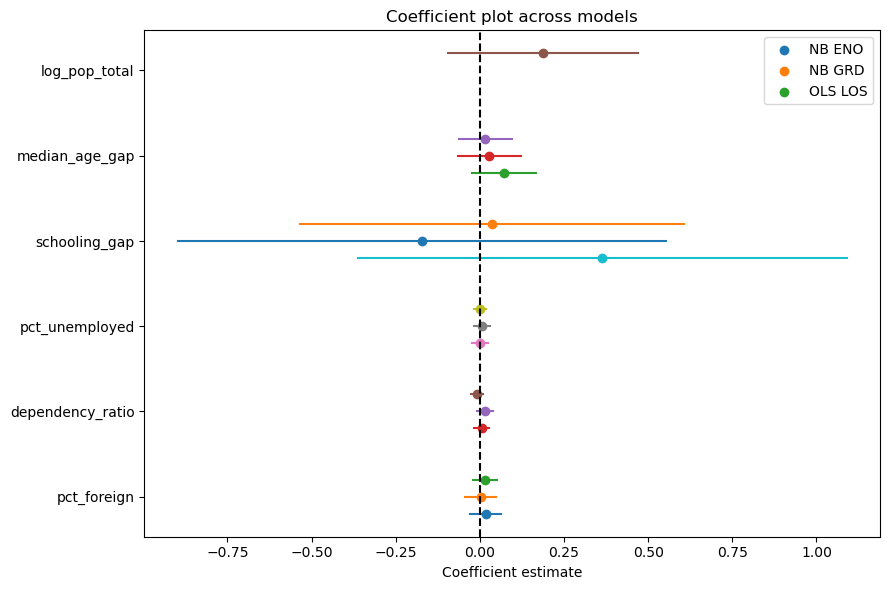

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

models_order = ["NB ENO", "NB GRD", "OLS LOS"]
offsets = {"NB ENO": -0.2, "NB GRD": 0.0, "OLS LOS": 0.2}

terms = coef_df["term"].unique().tolist()

for i, term in enumerate(terms):
    for model in models_order:
        row = coef_df[(coef_df["term"] == term) & (coef_df["model"] == model)]
        if len(row) == 0:
            continue
        
        y = i + offsets[model]
        coef = row["coef"].values[0]
        low = row["low"].values[0]
        high = row["high"].values[0]
        
        ax.plot([low, high], [y, y])
        ax.scatter(coef, y, label=model if i == 0 else "")

ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(range(len(terms)))
ax.set_yticklabels(terms)
ax.set_xlabel("Coefficient estimate")
ax.set_title("Coefficient plot across models")
ax.legend()
plt.tight_layout()
plt.show()

el gráfico resume los coeficientes de los tres modelos y permite comparar su signo, tamaño e incertidumbre. La línea vertical en 0 ayuda a ver qué efectos están más cerca de no tener una relación clara con el outcome.

En general, la mayoría de las covariables tiene coeficientes pequeños y con bastante incertidumbre, sobre todo en los modelos **NB ENO** y **NB GRD**. También se ve que **`schooling_gap`** es una de las variables más inestables entre modelos, mientras que **`pct_foreign`**, **`dependency_ratio`** y **`pct_unemployed`** se mantienen más cerca de 0.

En conjunto, esta figura refuerza que varias asociaciones existen, pero no todas están igual de bien definidas una vez que se usan modelos más exigentes.

### **6. Integrated synthesis**

Tomando juntas las tres tareas, la Región Metropolitana aparece como un espacio comunal muy desigual, donde el eje dominante mezcla **tamaño poblacional**, **estructura demográfica** y **posición socio-territorial**. La matriz de correlaciones de esta tarea lo deja claro: buena parte de los conteos sanitarios sigue el tamaño de la comuna, pero las tasas y outcomes continuos ya responden a patrones más complejos. No basta con decir “las comunas grandes tienen más casos”; también importan la dependencia etaria, la escolaridad y la composición social.
La relación entre ese perfil demográfico y el paisaje de salud existe, pero no es simple. Hay coincidencias claras, como el vínculo entre tamaño poblacional y carga bruta, y también entre `dependency_ratio` y `grd_rate_per_10k`. Pero hay desacoples igual de importantes: ENO y GRD no responden de la misma manera a las covariables, y el modelo OLS para `grd_mean_los` explicó poco. Eso sugiere que las desigualdades territoriales en salud no pueden resumirse en una sola dimensión demográfica. 

Lo que agrega Tarea 3, frente a mirar cada dataset por separado, es una capa de comparación más rigurosa. Al pasar de correlaciones a modelos, quedó claro que varios efectos que en Poisson parecían muy sólidos se debilitaban bastante al usar Negative Binomial, justo porque la sobre-dispersión era enorme. Ese resultado es importante por sí mismo: muestra que el desafío no era solo “encontrar asociaciones”, sino distinguir cuáles sobreviven cuando el modelo respeta mejor la variabilidad real de las comunas. 

La conclusión principal del notebook es que el territorio sí importa, pero de una manera más heterogénea y menos lineal de lo que una lectura rápida podría sugerir. Las comunas de la RM no solo difieren en tamaño o en proporción de población extranjera; también difieren en cómo esas características se traducen en resultados sanitarios observados. Por eso, el aporte del análisis ecológico acá no es entregar una verdad causal a nivel individual, sino mapear patrones territoriales, detectar comunas anómalas y dejar mejor formuladas las preguntas para un análisis posterior más fino. 

### **Creación del archivo CSV sobre el merge de los datos**

In [ ]:
import os

os.makedirs("output", exist_ok=True)
analytical_df.to_csv("output/tarea3_analytical_table.csv", index=False)